#1. Imports


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
import os
import matplotlib.pyplot as plt
from PIL import Image # To open images

#2. Globals



In [ ]:
# File paths
DRIVE_ZIP_PATH = '/content/drive/MyDrive/RRDataset_Proyecto/RRDataset_original_train_val.tar.gz'
LOCAL_DATA_PATH = '/content/dataset_extraido'

# Training parameters
BATCH_SIZE = 32
IMAGE_SIZE = 224  # Standard size for networks such as ResNet or ViT
EPOCHS = 10
LEARNING_RATE = 0.001

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#3. Utils


In [2]:
def accuracy(outputs, labels):
    """Calculate the accuracy for classification tasks."""
    _, preds = torch.max(outputs, 1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))



#4. Data Management


In [7]:
import os
import tarfile
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

# --- 1. ROUTE CONFIGURATION ---
ZIP_PATH = '/content/drive/MyDrive/RRDataset_proyecto/RRDataset_test.tar.gz'
LOCAL_DESTINATION = '/content/dataset_local'
os.makedirs(LOCAL_DESTINATION, exist_ok=True)

data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

counts = {}
max_fotos = 300  # <--- Extracting 300 from each (1800 photos in total)

print("Extracting a balanced sample...")

with tarfile.open(ZIP_PATH, 'r:gz') as tar:
    for member in tar.getmembers():
        if member.isfile() and member.name.lower().endswith(('.png', '.jpg', '.jpeg')):
            path_parts = member.name.split('/')

            clase = 'ai' if 'ai' in path_parts else 'real'
            if 'original' in path_parts: esc = 'original'
            elif 'transfer' in path_parts or 'internet' in path_parts: esc = 'transfer'
            elif 'redigital' in path_parts: esc = 'redigital'
            else: continue

            key = f"{clase}_{esc}"
            if counts.get(key, 0) < max_fotos:
                tar.extract(member, path=LOCAL_DESTINATION)
                counts[key] = counts.get(key, 0) + 1

print(f"Extraction completed: {sum(counts.values())} 10 images ready in local.")

# --- 2. PROFESIONAL DATASET AND SPLIT (TRAIN 80% / VAL 20%) ---
class RRDatasetLocal(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform
        for root, _, files in os.walk(root_dir):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    p = os.path.join(root, file)
                    p_parts = p.split('/')
                    c = 1 if 'ai' in p_parts else 0
                    if 'original' in p_parts: t = 0
                    elif 'transfer' in p_parts or 'internet' in p_parts: t = 1
                    else: t = 2
                    self.samples.append((p, c, t))

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, c, t = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, c, t

complete_dataset = RRDatasetLocal(LOCAL_DESTINATION, transform=data_transforms)
train_size = int(0.8 * len(complete_dataset))
val_size = len(complete_dataset) - train_size

train_dataset, val_dataset = random_split(complete_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Structured Dataset: {len(train_dataset)} to train | {len(val_dataset)} for pure validation.")

Extracting a balanced sample...


/tmp/ipykernel_4491/2882534819.py:37: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extract(member, path=LOCAL_DESTINATION)


Extraction completed: 1800 10 images ready in local.
Structured Dataset: 1440 to train | 360 for pure validation.


#5. Network Architecture


In [8]:
import torchvision.models as models

class MultiTaskModel(nn.Module):
    def __init__(self):
        super(MultiTaskModel, self).__init__()
        # We use pre-trained ResNet18 as a base (the "body" that recognizes shapes)
        self.base_model = models.resnet18(weights='IMAGENET1K_V1')

        # We save the number of input features of the last layer
        num_ftrs = self.base_model.fc.in_features

        # We remove the original ResNet final layer
        self.base_model.fc = nn.Identity()

        # We create the TWO exit "heads":
        # # 1. Head for Class (Real vs Fake) -> 2 outputs
        self.fc_class = nn.Linear(num_ftrs, 2)

        # # 2. Stage Head (Original, Transfer, Redigital) -> 3 outputs
        self.fc_trans = nn.Linear(num_ftrs, 3)

    def forward(self, x):
        # The image passes through the body of the network
        x = self.base_model(x)

        # The result is divided into the two tasks
        out_class = self.fc_class(x)
        out_trans = self.fc_trans(x)

        return out_class, out_trans

# We instantiate the model and move it to the GPU (if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MultiTaskModel().to(device)

print(f"Model configured and ready in: {device}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 163MB/s]


Model configured and ready in: cuda


In [9]:
# We check the first 5 images and the last 5 images of the dataset
print("--- First samples ---")
for i in range(5):
    path, l_class, l_trans = complete_dataset.samples[i]
    print(f"Photo: {os.path.basename(path)} | Class (Real=0, AI=1): {l_class} | scenario: {l_trans}")

print("\n--- Last samples ---")
for i in range(-5, 0):
    path, l_class, l_trans = complete_dataset.samples[i]
    print(f"Photo: {os.path.basename(path)} | Class (Real=0, AI=1): {l_class} | scenario: {l_trans}")

--- First samples ---
Photo: transfer_War_&_Conflict_Scenes_000134.jpg | Class (Real=0, AI=1): 1 | scenario: 1
Photo: transfer_production_000654.jpg | Class (Real=0, AI=1): 1 | scenario: 1
Photo: transfer_War_&_Conflict_Scenes_000252.jpg | Class (Real=0, AI=1): 1 | scenario: 1
Photo: transfer_normal_008915.jpg | Class (Real=0, AI=1): 1 | scenario: 1
Photo: transfer_normal_007166.jpg | Class (Real=0, AI=1): 1 | scenario: 1

--- Last samples ---
Photo: real_006422.jpg | Class (Real=0, AI=1): 0 | scenario: 0
Photo: real_004743.jpg | Class (Real=0, AI=1): 0 | scenario: 0
Photo: real_005035.jpg | Class (Real=0, AI=1): 0 | scenario: 0
Photo: real_000040.jpg | Class (Real=0, AI=1): 0 | scenario: 0
Photo: real_003158.jpg | Class (Real=0, AI=1): 0 | scenario: 0


#6. Training Loop


In [10]:
import torch
import torch.nn as nn

LAMBDA_CLASS = 0.5
LAMBDA_TRANS = 0.5

criterion_class = nn.CrossEntropyLoss()
criterion_trans = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
EPOCHS = 10

print(f"Starting Multi-Task training with {len(train_dataset)} samples...")

for epoch in range(EPOCHS):
    model.train()
    running_train_loss = 0.0
    for images, labels_class, labels_trans in train_loader:
        images, labels_class, labels_trans = images.to(device), labels_class.to(device), labels_trans.to(device)

        optimizer.zero_grad()
        outputs_class, outputs_trans = model(images)

        loss_class = criterion_class(outputs_class, labels_class)
        loss_trans = criterion_trans(outputs_trans, labels_trans)
        total_loss = (LAMBDA_CLASS * loss_class) + (LAMBDA_TRANS * loss_trans)

        total_loss.backward()
        optimizer.step()
        running_train_loss += total_loss.item()

    # Real-time validation (strict exam)
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for images, labels_class, labels_trans in val_loader:
            images, labels_class, labels_trans = images.to(device), labels_class.to(device), labels_trans.to(device)
            outputs_class, outputs_trans = model(images)

            v_loss_class = criterion_class(outputs_class, labels_class)
            v_loss_trans = criterion_trans(outputs_trans, labels_trans)
            running_val_loss += (LAMBDA_CLASS * v_loss_class) + (LAMBDA_TRANS * v_loss_trans)

    print(f"Epoch [{epoch+1}/{EPOCHS}] -> Loss Train: {running_train_loss/len(train_loader):.4f} | Loss Val (New photos): {running_val_loss/len(val_loader):.4f}")

# Secure saving
torch.save(model.state_dict(), '/content/drive/MyDrive/modelo_multitarea_final.pth')
print("Model saved in Drive")

Starting Multi-Task training with 1440 samples...
Epoch [1/10] -> Loss Train: 0.7490 | Loss Val (New photos): 0.6448
Epoch [2/10] -> Loss Train: 0.2967 | Loss Val (New photos): 0.5689
Epoch [3/10] -> Loss Train: 0.1156 | Loss Val (New photos): 0.5736
Epoch [4/10] -> Loss Train: 0.0468 | Loss Val (New photos): 0.6874
Epoch [5/10] -> Loss Train: 0.0269 | Loss Val (New photos): 0.6506
Epoch [6/10] -> Loss Train: 0.0185 | Loss Val (New photos): 0.6143
Epoch [7/10] -> Loss Train: 0.0241 | Loss Val (New photos): 0.7625
Epoch [8/10] -> Loss Train: 0.0241 | Loss Val (New photos): 0.6472
Epoch [9/10] -> Loss Train: 0.0195 | Loss Val (New photos): 0.6897
Epoch [10/10] -> Loss Train: 0.0140 | Loss Val (New photos): 0.7704
Model saved in Drive


#7. Evaluation

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import random  # <-- We import the library to generate randomness

def test_and_display_random(model, dataset, n_images=5):
    model.eval()
    fig, axes = plt.subplots(1, n_images, figsize=(22, 6))

    dic_class = {0: "REAL", 1: "AI (FAKE)"}
    dic_trans = {0: "Original", 1: "Internet/Transfer", 2: "Screen (Redigital)"}

    # KEY CHANGE: We choose 'n_images' (5) indexes completely at random without repeating
    indexes = random.sample(range(len(dataset)), n_images)

    for idx, i in enumerate(indexes):
        img, label_class, label_trans = dataset[i]

        with torch.no_grad():
            output_class, output_trans = model(img.unsqueeze(0).to(device))

            pred_class = torch.argmax(output_class, dim=1).item()
            pred_trans = torch.argmax(output_trans, dim=1).item()

        # We undo the normalization to paint the photo properly
        img_display = img.permute(1, 2, 0).cpu().numpy()
        img_display = img_display * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
        img_display = np.clip(img_display, 0, 1)

        axes[idx].imshow(img_display)

        txt_real_class = dic_class[label_class]
        txt_pred_class = dic_class[pred_class]

        txt_real_trans = dic_trans[label_trans]
        txt_pred_trans = dic_trans[pred_trans]

        # Green if everything is right, red if there is something wrong
        color_title = 'green' if (label_class == pred_class and label_trans == pred_trans) else 'red'

        title = f"CLASS:\nReal: {txt_real_class}\nPred: {txt_pred_class}\n\n"
        title += f"SCENARY:\nReal: {txt_real_trans}\nPred: {txt_pred_trans}"

        axes[idx].set_title(title, color=color_title, fontsize=10, loc='left')
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()



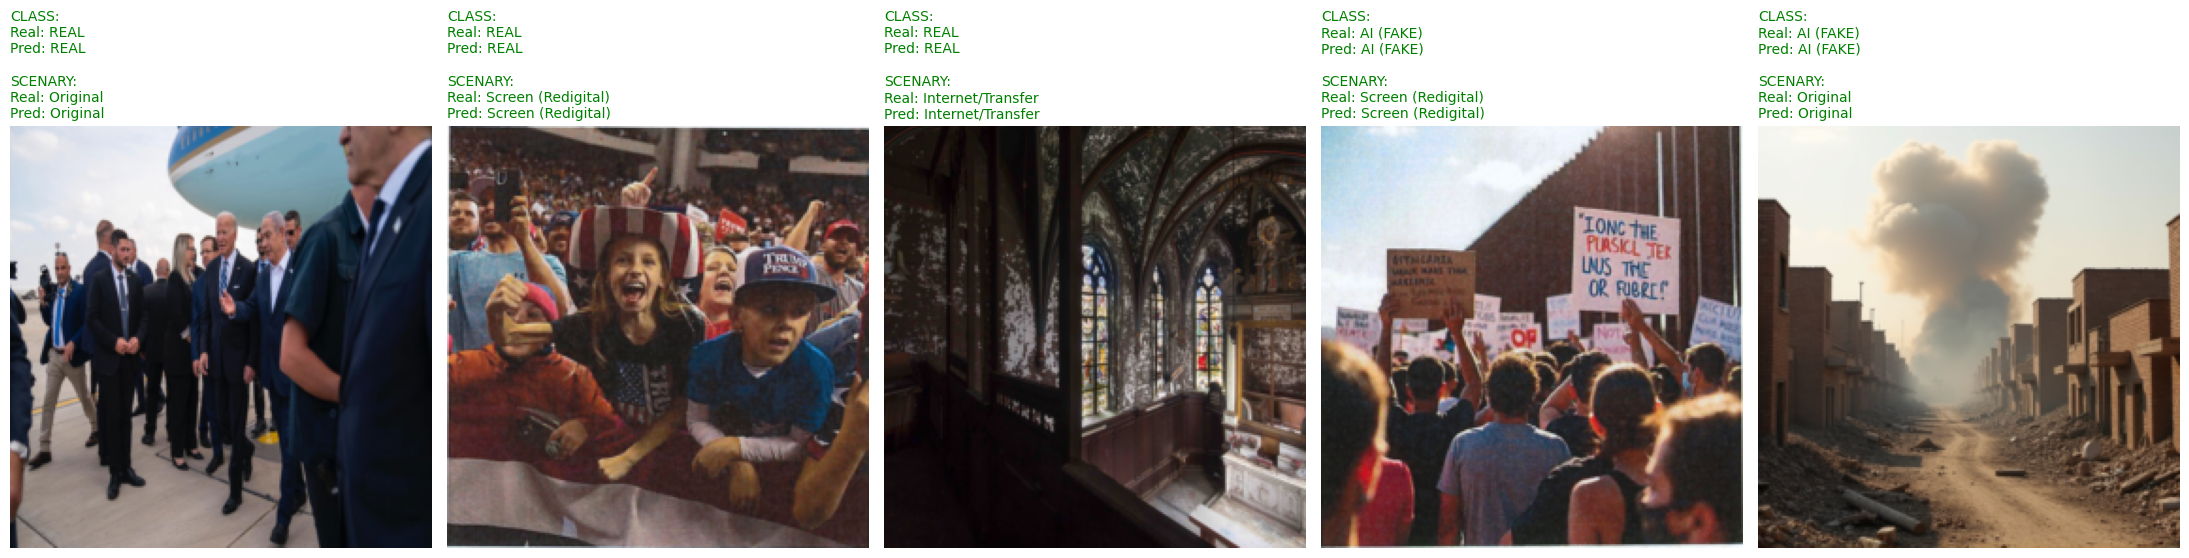

In [12]:
test_and_display_random(model, complete_dataset)

#8. Metrics & Analytics

Calculating global metrics...

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

        Real       0.85      0.89      0.87       165
   AI (Fake)       0.90      0.87      0.88       195

    accuracy                           0.88       360
   macro avg       0.88      0.88      0.88       360
weighted avg       0.88      0.88      0.88       360



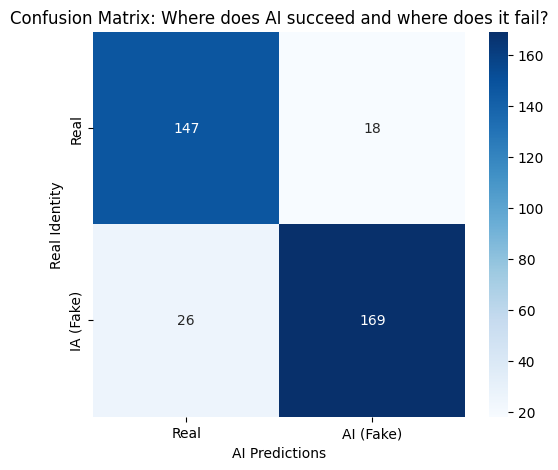

In [13]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_full_model(model, loader):
    model.eval()
    all_tags = []
    all_predictions = []

    print("Calculating global metrics...")

    with torch.no_grad():
        for images, labels_class, _ in loader:
            images = images.to(device)

            # AI Predictions
            outputs_class, _ = model(images)
            preds = torch.argmax(outputs_class, dim=1)

            # Save the results to compare
            all_tags.extend(labels_class.cpu().numpy())
            all_predictions.extend(preds.cpu().numpy())

    # 1. Print text report (Precision, Recall, F1-Score)
    print("\nCLASSIFICATION REPORT:")
    print(classification_report(all_tags, all_predictions, target_names=['Real', 'AI (Fake)']))

    # 2. Draw Visual Confusion Matrix
    cm = confusion_matrix(all_tags, all_predictions)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'AI (Fake)'], yticklabels=['Real', 'IA (Fake)'])
    plt.xlabel('AI Predictions')
    plt.ylabel('Real Identity')
    plt.title('Confusion Matrix: Where does AI succeed and where does it fail?')
    plt.show()


#We forced the final exam to use the 360 ​​new validation photos
evaluate_full_model(model, val_loader)